# H5T0_CNN: implement a 2D CNN using PyTorch for image classification

### create your "signature":
#### Run the cell but do NOT modify the cell
#### The signature needs to be displayed right below the cell in this file

In [1]:
import platform, socket, getpass
from time import time
from datetime import datetime
import random
signature_for_cnn=[socket.gethostbyname(socket.gethostname()),
                   getpass.getuser(),
                   datetime.now(),
                   random.random()]
print(signature_for_cnn) 

['127.0.0.1', 'jademuyambo', datetime.datetime(2025, 11, 26, 20, 52, 18, 441797), 0.928211200391676]


In [ ]:
#sample code to save model and signature
#torch.save({"model":model.state_dict(),
#            "signature":signature_for_cnn},
#            "CNN_best.pt") 

### This is a complete application of image classification using a 2D CNN
steps: \
define a 2D CNN \
define a function for training the CNN \
define a function for testing the CNN \
define a function for saving the model and your `signature_for_cnn` \
load data \
train the CNN in a for loop using the training set and the validation set\
evalaute the best model on the test set\
display accuracy and confusion matrix for each of the three sets: train, validation, and test sets
### you may use the code in lecture nodes
### write your code below this line

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [26]:
data = torch.load("H5T0_train_val_test_data.pt", weights_only=False, map_location="cpu")

X_train = data["X_train"]
Y_train = data["Y_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]
X_test = data["X_test"]
Y_test = data["Y_test"]

print("X shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Y shapes:", Y_train.shape, Y_val.shape, Y_test.shape)
print("X range :", float(X_train.min()), float(X_train.max()))
print("dtypes  :", X_train.dtype, Y_train.dtype)

X shapes: (1000, 28, 28) (1000, 28, 28) (1000, 28, 28)
Y shapes: (1000,) (1000,) (1000,)
X range : 0.0 1.0
dtypes  : float32 int64


In [27]:
class FashionDataset(Dataset):
    def __init__(self, X, Y):
        if not torch.is_tensor(X):
            X = torch.tensor(X)
        if not torch.is_tensor(Y):
            Y = torch.tensor(Y)
        self.X = X.float()
        self.Y = Y.long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        x = x.unsqueeze(0)
        y = self.Y[idx]
        return x, y
        

In [28]:
batch_size = 128

train_loader = DataLoader(FashionDataset(X_train, Y_train), batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(FashionDataset(X_val, Y_val), batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(FashionDataset(X_test, Y_test), batch_size=batch_size, shuffle=True, num_workers=0)

In [35]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.35):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool  = nn.MaxPool2d(2)
        self.drop  = nn.Dropout(dropout)

        self.fc1   = nn.Linear(128 * 3 * 3, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.reshape(x.size(0), -1)
        x = self.drop(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [37]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=10, dropout=0.35).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)

In [38]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total = 0
    total_correct = 0
    all_true, all_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)

        total_correct += (pred == y).sum().item()
        total += y.size(0)

        all_true.append(y.cpu())
        all_pred.append(pred.cpu())

    acc = total_correct / total
    all_true = torch.cat(all_true).numpy()
    all_pred = torch.cat(all_pred).numpy()
    return acc, all_true, all_pred

In [39]:
def confusion_matrix_np(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

num_epochs = 100
best_val_acc = -1.0
best_epoch = -1

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        running_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        running_total += y.size(0)

    scheduler.step()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_acc, _, _ = evaluate(model, val_loader)

    print(f"epoch {epoch:02d} | train loss {train_loss:.4f} | train accident {train_acc:.4f} | val acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "signature": signature_for_cnn,
                "other": signature_for_cnn,
            },
            "CNN_best.pt",
        )
print("\nBest epoch:", best_epoch, "best val acc:", best_val_acc)
print("Saved: CNN_best.pt")
        

epoch 00 | train loss 1.5349 | train accident 0.4540 | val acc 0.4630
epoch 01 | train loss 0.8131 | train accident 0.6950 | val acc 0.6000
epoch 02 | train loss 0.6558 | train accident 0.7430 | val acc 0.6770
epoch 03 | train loss 0.5220 | train accident 0.7980 | val acc 0.7460
epoch 04 | train loss 0.4440 | train accident 0.8360 | val acc 0.7880
epoch 05 | train loss 0.3742 | train accident 0.8500 | val acc 0.7770
epoch 06 | train loss 0.3538 | train accident 0.8690 | val acc 0.8140
epoch 07 | train loss 0.2875 | train accident 0.8940 | val acc 0.8220
epoch 08 | train loss 0.2550 | train accident 0.9050 | val acc 0.8070
epoch 09 | train loss 0.2180 | train accident 0.9260 | val acc 0.8000
epoch 10 | train loss 0.1906 | train accident 0.9330 | val acc 0.8330
epoch 11 | train loss 0.1457 | train accident 0.9470 | val acc 0.8330
epoch 12 | train loss 0.1094 | train accident 0.9630 | val acc 0.8180
epoch 13 | train loss 0.0887 | train accident 0.9720 | val acc 0.8280
epoch 14 | train los

In [40]:
ckpt = torch.load("CNN_best.pt", weights_only=False, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval

train_acc, ytr, ptr = evaluate(model, train_loader)
val_acc, yv, pv = evaluate(model, val_loader)
test_acc, yte, pte = evaluate(model, test_loader)

print("Accuracy train:", train_acc)
print("Accuracy val  :", val_acc)
print("Accuracy test :", test_acc)

Accuracy train: 1.0
Accuracy val  : 0.865
Accuracy test : 0.841


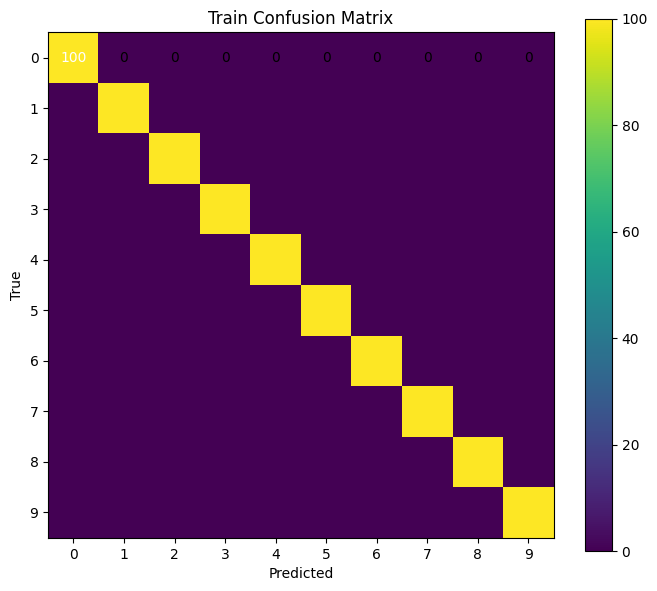

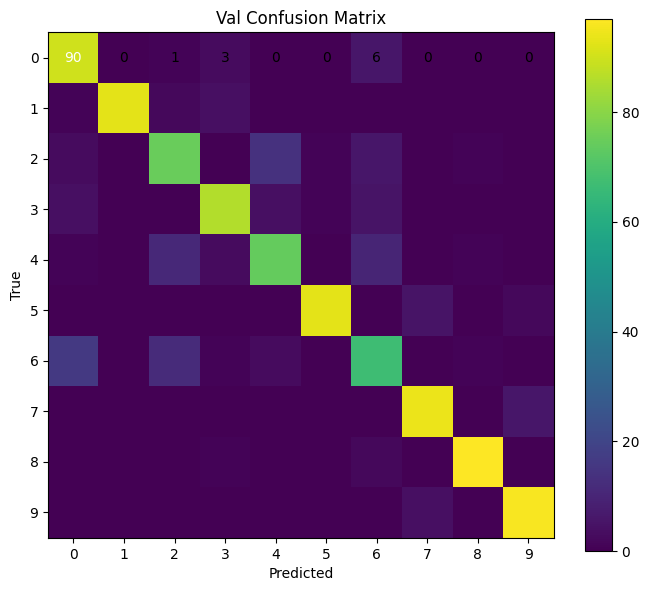

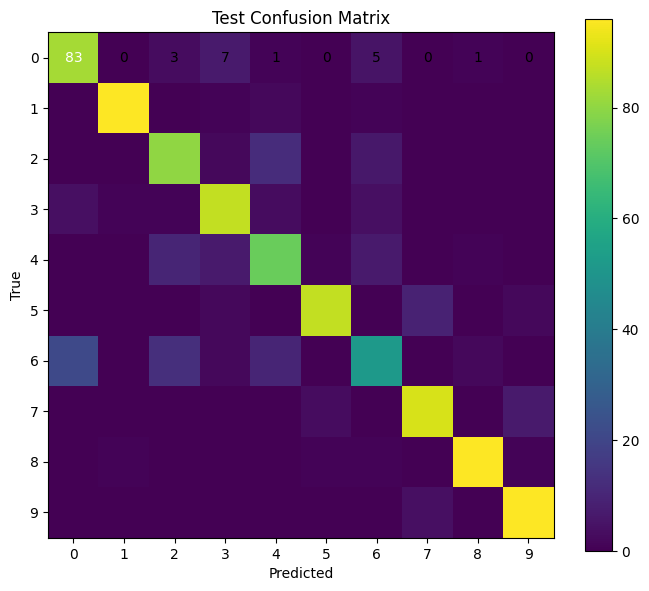

In [41]:
cm_train = confusion_matrix_np(ytr, ptr, num_classes=10)
cm_val = confusion_matrix_np(yv, pv, num_classes=10)
cm_test = confusion_matrix_np(yte, pte, num_classes=10)

def plot_confusion_matrix(cm, title="Confusion Matrix", show_ticks=False):
    cm = np.array(cm)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    fig.colorbar(im, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    if show_ticks:
        ticks = np.arange(cm.shape[0])
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{int(cm[i, j])}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
        fig.tight_layout()
        plt.show()

plot_confusion_matrix(cm_train, title="Train Confusion Matrix", show_ticks=True)
plot_confusion_matrix(cm_val, title="Val Confusion Matrix", show_ticks=True)
plot_confusion_matrix(cm_test, title="Test Confusion Matrix", show_ticks=True)

    